In [ ]:
# @title Configuração do Ambiente e Instalação de Dependências
!pip install --no-cache-dir transformers[torch] datasets evaluate accelerate scikit-learn

import os
import torch
import numpy as np
import pandas as pd
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

try:
    import evaluate
    HAS_EVALUATE = True
except ImportError:
    HAS_EVALUATE = False
    print("Aviso: 'evaluate' não disponível. Usaremos fallback para metrics.")

torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Utilizando o dispositivo: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 46.7 MB/s eta 0:00:00
Utilizando o dispositivo: cuda


### 1. Carregamento e Preparação dos Dados


In [ ]:
import pandas as pd

paths = [
    "/content/drive/MyDrive/MINA-BR-Rotulada.csv",
    "/content/drive/MyDrive/dataset_misoginia_finalizado.csv",
    "/content/drive/MyDrive/dados_artificiais.csv"
]

def load_and_preprocess(path):
    try:
        df = pd.read_csv(path)
    except:
        df = pd.read_csv(path, sep=';')

    print(f"Arquivo: {path.split('/')[-1]} | Colunas: {df.columns.tolist()}")
    return df

dfs = [load_and_preprocess(p) for p in paths]

display(dfs[0].head())

Arquivo: MINA-BR-Rotulada.csv | Colunas: ['certeza_disc_clas_1', 'certeza_disc_clas_2', 'certeza_disc_clas_3', 'certeza_ofens_clas_1', 'certeza_ofens_clas_2', 'certeza_ofens_clas_3', 'comment', 'date', 'disc_clas_1', 'disc_clas_2', 'disc_clas_3', 'id_autor_1', 'id_autor_2', 'id_autor_3', 'keyword', 'ofens_clas_1', 'ofens_clas_2', 'ofens_clas_3', 'source', 'odio']
Arquivo: dataset_misoginia_finalizado.csv | Colunas: ['certeza_disc_clas_1', 'certeza_disc_clas_2', 'certeza_disc_clas_3', 'certeza_ofens_clas_1', 'certeza_ofens_clas_2', 'certeza_ofens_clas_3', 'comment', 'date', 'disc_clas_1', 'disc_clas_2', 'disc_clas_3', 'id_autor_1', 'id_autor_2', 'id_autor_3', 'keyword', 'ofens_clas_1', 'ofens_clas_2', 'ofens_clas_3', 'source', 'odio', 'label_assedio', 'label_ameaca', 'label_descredito', 'label_misoginia_geral']
Arquivo: dados_artificiais.csv | Colunas: ['id', 'texto', 'rotulo']


,certeza_disc_clas_1,certeza_disc_clas_2,certeza_disc_clas_3,certeza_ofens_clas_1,certeza_ofens_clas_2,certeza_ofens_clas_3,comment,date,disc_clas_1,disc_clas_2,disc_clas_3,id_autor_1,id_autor_2,id_autor_3,keyword,ofens_clas_1,ofens_clas_2,ofens_clas_3,source,odio
0,-1.0,-1.0,4.0,4.0,5.0,4.0,Eu fui ver o Twitter da garota e já dou de car...,2020-12-23 21:17:31,0.0,0.0,1.0,-MbqEhLQ5DHE4JKVnSYz,-MbrOtpTLDyCIXXqMS8s,-MbxUAktPHOvanZLgccl,antifeminista,0.0,0.0,1.0,Twitter,0
1,5.0,1.0,5.0,5.0,5.0,5.0,@NOME @NOME Jaja te bloqueio denovo seu resto ...,2020-12-27 20:51:47,0.0,0.0,1.0,-MbrXeGPm84uPDqKwzsp,-MbxCpLCV0T1V7o0TS8U,-Mc-A6HAii__JnTbfS87,mal_comida,1.0,1.0,1.0,Twitter,0
2,-1.0,-1.0,-1.0,5.0,5.0,5.0,@NOME @NOME @NOME @NOME O link n ta abrindo p ...,2020-12-24 14:16:29,0.0,0.0,0.0,-MbpxGPiip0WCKKay75Y,-MbxAkmihTQeEppUb3js,-MbxCzO_1ftJ-VJJcgJv,antifeminista,0.0,0.0,0.0,Twitter,0
3,-1.0,-1.0,-1.0,4.0,5.0,5.0,Quando vejo uma mulher antifeminista eu só con...,2020-12-23 19:31:28,0.0,0.0,0.0,-MbneJBhF1GNC7xPlc-V,-MbqFQINR5epWplcJrfU,-Mbwgys1T2GNBckrws-l,antifeminista,0.0,0.0,0.0,Twitter,0
4,5.0,5.0,4.0,5.0,5.0,3.0,@NOME Mulher bonita e sem frescuras 😍😍😍....o t...,2020-12-20 18:04:36,1.0,1.0,1.0,-MbqHpEUMADtFHR3ci3y,-MbvHmh93AGhmpw2J54j,-MbxDaKZSOQDgemnY-H6,feminazi,1.0,1.0,1.0,Twitter,1


### 2. Unificação e Mapeamento de Categorias


In [ ]:
for i in range(len(dfs)):
    rename_dict = {
        'comment': 'text',
        'texto': 'text',
        'rotulo': 'label',
        'odio': 'label'
    }
    dfs[i] = dfs[i].rename(columns=rename_dict)

df_final = pd.concat([df[['text', 'label']] for df in dfs if 'text' in df.columns and 'label' in df.columns], ignore_index=True)

df_final = df_final.dropna(subset=['text', 'label'])
df_final = df_final.drop_duplicates(subset=['text'])

print(f"Total de exemplos após unificação: {len(df_final)}")
print("Distribuição inicial das classes:")
print(df_final['label'].value_counts())

display(df_final.head())

Total de exemplos após unificação: 3801
Distribuição inicial das classes:
label
0                         1738
Misoginia Geral            448
Assédio Sexual             443
Descrédito Intelectual     363
1                          338
Ameaça Física              255
Não-Misógino               215
rotulo                       1
Name: count, dtype: int64


,text,label
0,Eu fui ver o Twitter da garota e já dou de car...,0
1,@NOME @NOME Jaja te bloqueio denovo seu resto ...,0
2,@NOME @NOME @NOME @NOME O link n ta abrindo p ...,0
3,Quando vejo uma mulher antifeminista eu só con...,0
4,@NOME Mulher bonita e sem frescuras 😍😍😍....o t...,1


### 3. Mapeamento para Categorias Alvo
Dicionário de mapeamento para consolidar as diversas labels dos datasets originais nas 5 categorias desejadas.

In [ ]:
target_categories = [
    "Descrédito Intelectual",
    "Assédio Sexual",
    "Misoginia Geral",
    "Ameaça Física",
    "Não-Misógino"
]

mapping = {
    0: "Não-Misógino",
    1: "Misoginia Geral",
    "0": "Não-Misógino",
    "1": "Misoginia Geral",
    "Não-Misógino": "Não-Misógino",
    "Misoginia Geral": "Misoginia Geral",
    "Assédio Sexual": "Assédio Sexual",
    "Descrédito Intelectual": "Descrédito Intelectual",
    "Ameaça Física": "Ameaça Física"
}

df_final['label'] = df_final['label'].map(lambda x: mapping.get(x, x))

df_final = df_final[df_final['label'].isin(target_categories)].copy()

labels = sorted(df_final['label'].unique())
id2label = {i: label for i, label in enumerate(labels)}
label2id = {label: i for i, label in enumerate(labels)}

df_final['label_id'] = df_final['label'].map(label2id)

print("Distribuição Final por Categoria:")
print(df_final['label'].value_counts())
display(df_final.head())

Distribuição Final por Categoria:
label
Não-Misógino              1953
Misoginia Geral            786
Assédio Sexual             443
Descrédito Intelectual     363
Ameaça Física              255
Name: count, dtype: int64


,text,label,label_id
0,Eu fui ver o Twitter da garota e já dou de car...,Não-Misógino,4
1,@NOME @NOME Jaja te bloqueio denovo seu resto ...,Não-Misógino,4
2,@NOME @NOME @NOME @NOME O link n ta abrindo p ...,Não-Misógino,4
3,Quando vejo uma mulher antifeminista eu só con...,Não-Misógino,4
4,@NOME Mulher bonita e sem frescuras 😍😍😍....o t...,Misoginia Geral,3


### 4. Tokenização e Divisão dos Dados
Tokenizador do BERTimbau e preparar o dataset para o treinamento.

In [ ]:
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split

model_checkpoint = "neuralmind/bert-large-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

dataset = Dataset.from_pandas(df_final[['text', 'label_id']].rename(columns={'label_id': 'label'}))

train_testvalid = dataset.train_test_split(test_size=0.2, seed=42)

tokenized_datasets = train_testvalid.map(tokenize_function, batched=True)

print("Tokenização concluída.")
print(tokenized_datasets)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/155 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/3040 [00:00<?, ? examples/s]

Map:   0%|          | 0/760 [00:00<?, ? examples/s]

Tokenização concluída.
DatasetDict({
    train: Dataset({
        features: ['text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3040
    })
    test: Dataset({
        features: ['text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 760
    })
})


### 5. Melhores Práticas para Dados Desbalanceados
Calculando pesos para equilibrar a importância das classes minoritárias durante o treinamento.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import torch
from torch import nn

y_train = tokenized_datasets['train']['label']
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

print("Pesos calculados por classe:")
for i, w in enumerate(weights):
    print(f"{id2label[i]}: {w:.2f}")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

Pesos calculados por classe:
Ameaça Física: 3.20
Assédio Sexual: 1.70
Descrédito Intelectual: 2.03
Misoginia Geral: 0.95
Não-Misógino: 0.39


### 6. Novo Treinamento com Hiperparâmetros Otimizados


In [ ]:
import evaluate
import numpy as np
from transformers import BertForSequenceClassification

metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels, average="macro")

new_training_args = TrainingArguments(
    output_dir="./results_optimized",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=10,
    report_to="none"
)

model_opt = BertForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(target_categories)
)

optimized_trainer = WeightedTrainer(
    model=model_opt,
    args=new_training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

print("Iniciando treinamento otimizado com correção de erro...")
optimized_trainer.train()

pytorch_model.bin:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-large-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from t

Iniciando treinamento otimizado com correção de erro...


Epoch,Training Loss,Validation Loss,F1
1,0.451783,0.434304,0.801551
2,0.160327,0.303337,0.899008
3,0.089547,0.304422,0.898891


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=570, training_loss=0.5049203764974025, metrics={'train_runtime': 1029.6363, 'train_samples_per_second': 8.857, 'train_steps_per_second': 0.554, 'total_flos': 2124825046179840.0, 'train_loss': 0.5049203764974025, 'epoch': 3.0})

### 7. Configuração do Modelo e Treinamento


In [ ]:
from transformers import TrainingArguments, Trainer, BertForSequenceClassification
import evaluate

metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels, average="macro")

model = BertForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(target_categories)
)

training_args = TrainingArguments(
    output_dir="./results_misoginia",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=10,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

print("Modelo pronto para iniciar o treinamento.")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-large-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from t

Modelo pronto para iniciar o treinamento.


### 8. Execução do Fine-tuning


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,0.309639,0.302922,0.902142
2,0.133325,0.340677,0.898130
3,0.022889,0.431781,0.895141


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=570, training_loss=0.2773915638003433, metrics={'train_runtime': 1085.9918, 'train_samples_per_second': 8.398, 'train_steps_per_second': 0.525, 'total_flos': 2124825046179840.0, 'train_loss': 0.2773915638003433, 'epoch': 3.0})

### 9. Avaliação Qualitativa e Quantitativa
Métricas finais no conjunto de teste e visualizar o desempenho por categoria através de uma matriz de confusão.

                        precision    recall  f1-score   support

         Ameaça Física       0.92      0.91      0.91        65
        Assédio Sexual       0.96      0.93      0.95        86
Descrédito Intelectual       0.94      0.95      0.95        64
       Misoginia Geral       0.76      0.79      0.77       143
          Não-Misógino       0.92      0.91      0.91       402

              accuracy                           0.89       760
             macro avg       0.90      0.90      0.90       760
          weighted avg       0.89      0.89      0.89       760



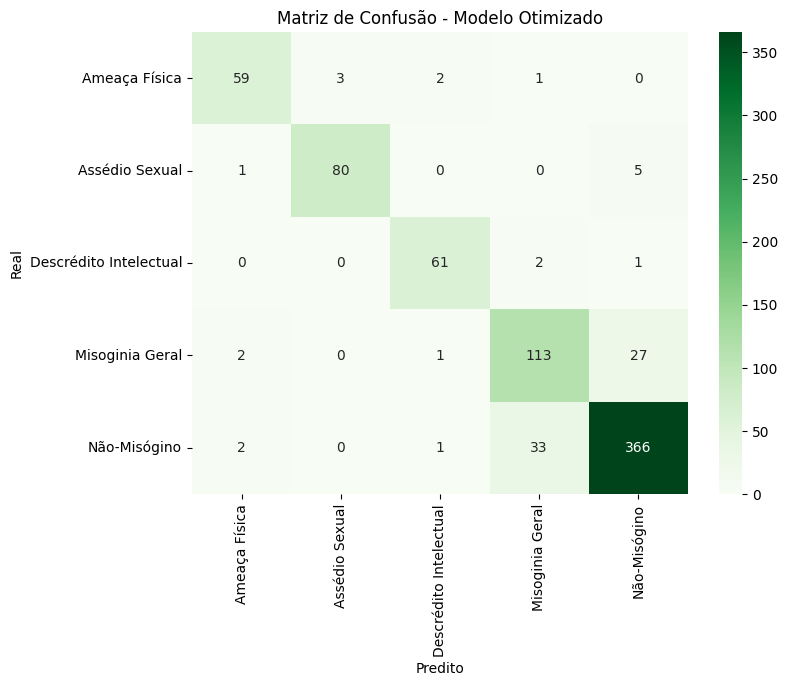

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

predictions = optimized_trainer.predict(tokenized_datasets["test"])
y_probs = torch.nn.functional.softmax(torch.from_numpy(predictions.predictions), dim=-1).numpy()
y_pred = np.argmax(y_probs, axis=-1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred, target_names=labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Greens')
plt.title('Matriz de Confusão - Modelo Otimizado')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

### 10. Teste Prático (Inferência)


In [ ]:
import re

def clean_text(text):
    text = re.sub(r'[\x00-\x1F\x7F-\x9F]', '', text)
    return text.strip()

def predict_misogyny_optimized(text):
    cleaned_text = clean_text(text)
    inputs = tokenizer(cleaned_text, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
    model_opt.eval()
    with torch.no_grad():
        outputs = model_opt(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    pred_idx = torch.argmax(probs).item()

    return {
        "categoria": id2label[pred_idx],
        "confianca": f"{probs[0][pred_idx].item():.2%}"
    }

testes = [
    "Lugar de mulher é na cozinha, ela não entende nada de política.",
    "Você é muito burra para discutir esse assunto de economia.",
    "Vou te pegar na saída da faculdade e você vai ver o que te espera."
]

print("--- Teste de Inferência Robusta ---")
for t in testes:
    res = predict_misogyny_optimized(t)
    print(f"Texto: {t}\nResultado: {res['categoria']} ({res['confianca']})\n")

--- Teste de Inferência Robusta ---
Texto: Lugar de mulher é na cozinha, ela não entende nada de política.
Resultado: Misoginia Geral (74.03%)

Texto: Você é muito burra para discutir esse assunto de economia.
Resultado: Descrédito Intelectual (88.39%)

Texto: Vou te pegar na saída da faculdade e você vai ver o que te espera.
Resultado: Ameaça Física (98.67%)



In [ ]:
import shutil
import os

save_directory = "./modelo_misoginia_final"
drive_path = "/content/drive/MyDrive/modelo_misoginia_final"

print("Salvando modelo e tokenizador...")
model_opt.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

import json
with open(os.path.join(save_directory, "label_mapping.json"), "w", encoding="utf-8") as f:
    json.dump({"id2label": id2label, "label2id": label2id}, f, ensure_ascii=False)

try:
    shutil.copytree(save_directory, drive_path, dirs_exist_ok=True)
    print(f"Sucesso! O modelo foi salvo no Google Drive em: {drive_path}")
    print("Você pode baixar essa pasta e usá-la no seu app do Streamlit.")
except Exception as e:
    print(f"Ocorreu um erro ao copiar para o Drive (verifique se ele está montado): {e}")
    print(f"O modelo está salvo localmente em: {save_directory}")

Salvando modelo e tokenizador...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Sucesso! O modelo foi salvo no Google Drive em: /content/drive/MyDrive/modelo_misoginia_final
Você pode baixar essa pasta e usá-la no seu app do Streamlit.
